In [1]:
try:
    import shap
except:
    %pip install shap
    import shap

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 0.0/1.1 MB ? eta -:--:--

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 18.3 MB/s eta 0:00:00



[notice] A new release of pip is available: 25.0.1 -> 26.0
[notice] To update, run: pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.


In [2]:
## -- System dependencies --
import sys, os, gc
import torch

## -- Device-Agnostic for GPU --
if torch.cuda.is_available():
    print(f"ℹ️ Device GPU: {torch.cuda.get_device_name(0)}")
    print(f"ℹ️ No. of CPU: {os.cpu_count()} cores")
    # get_ipython().run_line_magic('load_ext', 'cudf.pandas')
    # get_ipython().run_line_magic('load_ext', 'cuml.accel')
    # from cuml.preprocessing import TargetEncoder as cuTE
else:
    print(f"ℹ️ Device: CPU {os.cpu_count()} cores")

ℹ️ Device: CPU 224 cores


In [3]:
## -- Data Manipulation --
import numpy as np, pandas as pd, random

## -- Visualization --
from IPython.display import display, Image
import matplotlib.pyplot as plt
import seaborn as sns

## -- Functional Tools --
from time import time, sleep
from tqdm.notebook import tqdm
from itertools import combinations, product

## -- Machine Learning --
import sklearn
from sklearn.ensemble import HistGradientBoostingRegressor, ExtraTreesRegressor
from sklearn.model_selection import KFold, StratifiedKFold, train_test_split
from sklearn.metrics import root_mean_squared_error, PredictionErrorDisplay

import warnings

In [4]:
## -- Global Settings --
# sklearn.set_config(transform_output="pandas")
warnings.simplefilter('ignore')
warnings.filterwarnings('ignore')

# pd.options.mode.copy_on_write = True
pd.set_option('display.max_columns', 1000)
plt.style.use("ggplot")
# sns.set_style("whitegrid")
cmap = sns.diverging_palette(0, 230, 90, 60, as_cmap=True)
PALETTE = ['c', 'r', 'orange']

## -- Set Global Seed --
SEED = 42
np.random.seed(SEED)
random.seed(SEED)

COLOR = '\033[32m'
RESET = '\033[0m'

# from google.colab import data_table
# data_table.enable_dataframe_formatter()

In [5]:
## -- Load Data from Kaggle --
PATH = '/kaggle/input/playground-series-s6e1/'
submit = pd.read_csv(PATH+'sample_submission.csv')
train = pd.read_csv(PATH+'train.csv').drop('id', axis=1)
test = pd.read_csv(PATH+'test.csv').drop('id', axis=1)

TARGET = train.columns[-1]
NUMS = test.select_dtypes(include='number').columns.tolist()
CATS = test.select_dtypes(exclude='number').columns.tolist()
BASE = NUMS + CATS

orig = pd.read_csv('/kaggle/input/exam-score-prediction-dataset/Exam_Score_Prediction.csv').drop('student_id', axis=1)

for (name, df) in dict(Train=train, Test=test, Original=orig).items():
    print(f"{name} shape: {df.shape}")

print(f"\nTotal Numerical: {len(NUMS)}")
print(f"Total Categorical: {len(CATS)}")
print(f"Total base features: {len(BASE)}")

Train shape: (630000, 12)
Test shape: (270000, 11)
Original shape: (20000, 12)

Total Numerical: 4
Total Categorical: 7
Total base features: 11


In [6]:
# ## -- Load data from Colab --
# from google.colab import drive
# drive.mount('/content/drive')

# PATH = '/content/drive/MyDrive/--colab--notebooks--/Ps6e1 | Student Test Score/student_test_dataset/'
# submit = pd.read_csv(PATH+'sample_submission.csv')
# train = pd.read_csv(PATH+'train.csv').drop('id', axis=1)
# test = pd.read_csv(PATH+'test.csv').drop('id', axis=1)
# orig = pd.read_csv(PATH+'Exam_Score_Prediction.csv').drop('student_id', axis=1)

# TARGET = train.columns[-1]
# NUMS = test.select_dtypes(include='number').columns.tolist()
# CATS = test.select_dtypes(exclude='number').columns.tolist()
# BASE = NUMS + CATS

# for (name, df) in dict(Train=train, Test=test, Original=orig).items():
#     print(f"{name} shape: {df.shape}")

# print(f"\nTotal Numerical: {len(NUMS)}")
# print(f"Total Categorical: {len(CATS)}")
# print(f"Total base features: {len(BASE)}")

In [7]:
# ## -- Check if id is unique --
# print(f"Train ID column is Unique: {train.id.is_unique}")
# print(f"Test ID column is Unique: {test.id.is_unique}")

In [8]:
display(train.head())
train.info()

,age,gender,course,study_hours,class_attendance,internet_access,sleep_hours,sleep_quality,study_method,facility_rating,exam_difficulty,exam_score
0,21,female,b.sc,7.91,98.8,no,4.9,average,online videos,low,easy,78.3
1,18,other,diploma,4.95,94.8,yes,4.7,poor,self-study,medium,moderate,46.7
2,20,female,b.sc,4.68,92.6,yes,5.8,poor,coaching,high,moderate,99.0
3,19,male,b.sc,2.00,49.5,yes,8.3,average,group study,high,moderate,63.9
4,23,male,bca,7.65,86.9,yes,9.6,good,self-study,high,easy,100.0


<class 'pandas.DataFrame'>
RangeIndex: 630000 entries, 0 to 629999
Data columns (total 12 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   age               630000 non-null  int64  
 1   gender            630000 non-null  str    
 2   course            630000 non-null  str    
 3   study_hours       630000 non-null  float64
 4   class_attendance  630000 non-null  float64
 5   internet_access   630000 non-null  str    
 6   sleep_hours       630000 non-null  float64
 7   sleep_quality     630000 non-null  str    
 8   study_method      630000 non-null  str    
 9   facility_rating   630000 non-null  str    
 10  exam_difficulty   630000 non-null  str    
 11  exam_score        630000 non-null  float64
dtypes: float64(4), int64(1), str(7)
memory usage: 80.0 MB


In [9]:
train.describe(include='number').T

,count,mean,std,min,25%,50%,75%,max
age,630000.0,20.545821,2.260238,17.000,19.00,21.0,23.00,24.00
study_hours,630000.0,4.002337,2.359880,0.080,1.97,4.0,6.05,7.91
class_attendance,630000.0,71.987261,17.430098,40.600,57.00,72.6,87.20,99.40
sleep_hours,630000.0,7.072758,1.744811,4.100,5.60,7.1,8.60,9.90
exam_score,630000.0,62.506672,18.916884,19.599,48.80,62.6,76.30,100.00


In [10]:
train.describe(exclude='number').T

,count,unique,top,freq
gender,630000,3,other,211097
course,630000,7,b.tech,131236
internet_access,630000,2,yes,579423
sleep_quality,630000,3,poor,213675
study_method,630000,5,coaching,131697
facility_rating,630000,3,medium,214082
exam_difficulty,630000,3,moderate,353982


In [11]:
## -- Unique value counts for each dataset --
TRAIN_UNIQUE = {}
ORIGINAL_UNIQUE = {}
TEST_UNIQUE = {}

for col in BASE:
    TRAIN_UNIQUE[col] = train[col].nunique()
    ORIGINAL_UNIQUE[col] = orig[col].nunique()
    TEST_UNIQUE[col] = test[col].nunique()

unique_counts_df = pd.concat(
        [pd.DataFrame(TRAIN_UNIQUE, index=['Train']),
         pd.DataFrame(ORIGINAL_UNIQUE, index=['Original']),
         pd.DataFrame(TEST_UNIQUE, index=['Test'])],
    )

unique_counts_df.style.background_gradient()

,age,study_hours,class_attendance,sleep_hours,gender,course,internet_access,sleep_quality,study_method,facility_rating,exam_difficulty
Train,8,792,617,66,3,7,2,3,5,3,3
Original,8,784,589,59,3,7,2,3,5,3,3
Test,8,786,604,64,3,7,2,3,5,3,3


## FEATURE ENGINEERING

In [12]:
# ## -- Factorize using combined data --
# for c in CATS:
#     combine  = pd.concat([train[c], test[c], orig[c]])
#     combine  = combine.factorize()[0]
#     train[c] = combine[:len(train)]
#     test[c]  = combine[len(train):len(train)+len(test)]
#     orig[c]  = combine[-len(orig):]

# ## -- Treat age(8 unique values) as category --
# NUMS.remove('age')
# CATS.append('age')

# print('Label encoding complete!')

In [13]:
# ## -- Append predicted columns as extra features --
# ## -- os.walk: Deep search with subfolders --
# def dataloader(filepath):    
#     train_df = pd.DataFrame()
#     test_df = pd.DataFrame()
    
#     # print("Loading .npy: ", end="")
#     # for (root, dirs, files) in os.walk(filepath):
#     #     for i, file in enumerate(sorted(files), 1):
#     #         if i%5 == 0: print(f"{i}%.. ", end="")
#     #         if file.endswith(".npy") and "train" in file:
#     #             train_path = np.load(os.path.join(root, file))
#     #             train = pd.concat([train, pd.Series(train_path, name=file[6:-4])], axis=1)
#     #         elif file.endswith(".npy") and "test" in file:
#     #             test_path = np.load(os.path.join(root, file))
#     #             test = pd.concat([test, pd.Series(test_path, name=file[5:-4])], axis=1)
#     # print()
#     print("Loading .parquet files: ", end="")
#     for (root, dirs, files) in os.walk(filepath):
#         for i, file in enumerate(sorted(files), 1):
#             if i%5 == 0: print(f"{i}%.. ", end="")
#             if file.endswith(".parquet") and "train" in file:
#                 train_path = os.path.join(root, file)
#                 train_df = pd.concat([train_df, pd.read_parquet(train_path)], axis=1)
#             elif file.endswith(".parquet") and "test" in file:
#                 test_path = os.path.join(root, file)
#                 test_df = pd.concat([test_df, pd.read_parquet(test_path)], axis=1)
#     print()
#     print(f"Total train models: {len(train_df.columns)} || Shape: {train_df.shape}")
#     print(f"Total test models : {len(test_df.columns)} || Shape: {test_df.shape}")
#     print()

#     return train_df, test_df

In [14]:
# PATHS = [
#     # '/kaggle/input/ps6e1-per-feature-ag',
#     '/kaggle/input/ps6e1-autogluon-trainorig',
#     # '/kaggle/input/ps6e1-lr-gbdt-nn-trainorig',
# ]

# ## -- Load dataframes --
# train_dfs = []
# test_dfs  = []

# ## -- Load train/test datasets --
# for p in PATHS:
#     tr, ts = dataloader(p)
#     train_dfs.append(tr)
#     test_dfs.append(ts)

# ## -- Concat datasets --
# ext_train = pd.concat(train_dfs, axis=1)
# ext_test  = pd.concat(test_dfs, axis=1)

# print('External data loaded', ext_train.shape, ext_test.shape)

# ## -- Drop weighted autogluon models --
# for c in ext_train.columns:
#     if 'L2' in c or 'L3' in c: # 
#         ext_train.drop([c], axis=1, inplace=True)
#         ext_test.drop([c], axis=1, inplace=True)
#     elif c == TARGET:
#         ext_train.drop([c], axis=1, inplace=True)
    
# ## -- Check for missing values --
# print('Check missingness:', ext_train.isna().sum().sum(), ext_test.isna().sum().sum())

# display(ext_train.head(3))
# display(ext_test.head(3))

In [15]:
# %%time

# plt.figure(figsize=(18, 5))
# ext_train.boxplot()
# # sns.boxplot(ext_train)
# plt.tick_params(axis='x', rotation=90)

In [16]:
# ## -- Merge datasets --
# top_cols = ext_train.columns.tolist()

# train = pd.concat([train, ext_train], axis=1)
# test = pd.concat([test, ext_test], axis=1)

# train.head(3)

In [17]:
for df_temp in [train, test, orig]:

    # df_temp['study_hours_squared'] = df_temp['study_hours'] ** 2
    # df_temp['study_hours_cubed'] = df_temp['study_hours'] ** 3
    # df_temp['class_attendance_squared'] = df_temp['class_attendance'] ** 2
    # df_temp['sleep_hours_squared'] = df_temp['sleep_hours'] ** 2
    # df_temp['age_squared'] = df_temp['age'] ** 2

    # df_temp['log_study_hours'] = np.log1p(df_temp['study_hours'])
    # df_temp['log_class_attendance'] = np.log1p(df_temp['class_attendance'])
    # df_temp['log_sleep_hours'] = np.log1p(df_temp['sleep_hours'])
    # df_temp['sqrt_study_hours'] = np.sqrt(df_temp['study_hours'])
    # df_temp['sqrt_class_attendance'] = np.sqrt(df_temp['class_attendance'])

    # # -- Interaction features --
    # df_temp['study_hours_times_attendance'] = df_temp['study_hours'] * df_temp['class_attendance']
    # df_temp['study_hours_times_sleep'] = df_temp['study_hours'] * df_temp['sleep_hours']
    # df_temp['attendance_times_sleep'] = df_temp['class_attendance'] * df_temp['sleep_hours']

    # # -- Ratio features (add small epsilon to avoid division by zero) --
    # eps = 1e-6
    # df_temp['study_hours_over_sleep'] = df_temp['study_hours'] / (df_temp['sleep_hours'] + eps)
    # df_temp['attendance_over_sleep'] = df_temp['class_attendance'] / (df_temp['sleep_hours'] + eps)

    ## -- Feature by: Vladimir Demidov
    ## -- https://www.kaggle.com/competitions/playground-series-s6e1/discussion/665915
    LUT = {
        'sleep_quality': {'good': 5, 'average': 0, 'poor': -5},
        'facility_rating': {'high': 4, 'medium': 0, 'low': -4},
        'study_method': {
            'coaching': 10,
            'mixed': 5,
            'group study': 2,
            'online videos': 1,
            'self-study': 0
        }
    }

    df_temp['formula'] = 6 * df_temp['study_hours'] + 0.35 * df_temp['class_attendance'] \
            + 1.5 * df_temp['sleep_hours'] + \
            + df_temp['sleep_quality'].map(LUT['sleep_quality']) \
            + df_temp['study_method'].map(LUT['study_method']) \
            + df_temp['facility_rating'].map(LUT['facility_rating'])

    ## -- Encode categorical variables to numeric ordinal values --
    ordinal_maps = {
        "internet_access": {"no":0, "yes":1},
        "gender": {"male":0, "female":1, "other":2},
        "sleep_quality": {"poor":0, "average":1, "good":2},
        "facility_rating": {"low":0, "medium":1, "high":2},
        "exam_difficulty": {"easy":0, "moderate":1, "hard":2},
        "course": {"ba":0, "b.sc":1, "diploma":2, "b.tech":3, "b.com":4, "bca":5, "bba":6},
        "study_method": {"self-study":0, "online videos":1, "group study":2, "mixed":3, "coaching":4},
    }

    for c in CATS:
        df_temp[c] = df_temp[c].map(ordinal_maps[c]).fillna(-1)

    # # -- Interaction between encoded categoricals and key numeric features --
    # df_temp['study_hours_times_sleep_quality'] = df_temp['study_hours'] * df_temp['sleep_quality']
    # df_temp['attendance_times_facility'] = df_temp['class_attendance'] * df_temp['facility_rating']
    # df_temp['sleep_hours_times_difficulty'] = df_temp['sleep_hours'] * df_temp['exam_difficulty']
    # df_temp['age_times_study_hours'] = df_temp['age'] * df_temp['study_hours']
    # df_temp['age_times_attendance'] = df_temp['age'] * df_temp['class_attendance']

    # ## -- Composite feature: learning efficiency --
    # df_temp['efficiency'] = (df_temp['study_hours'] * df_temp['class_attendance']) / (df_temp['sleep_hours'] + 1)
    # df_temp["study_efficiency"] = df_temp["study_hours"] * (df_temp["class_attendance"] / 100.0)

    # ## -- Cyclic encoding --
    # for p in [12, 14]:
    #     df_temp[f"study_hours_sin_{p}"] = np.sin(2 * np.pi * df_temp['study_hours'] / p).astype('float32')
    #     df_temp[f"class_attend_sin_{p}"] = np.sin(2 * np.pi * df_temp['class_attendance'] / p).astype('float32')

    total_features = [c for c in df_temp.columns if c != TARGET]
    print(f'Feature Engineered: {len(total_features)}')

Feature Engineered: 12


Feature Engineered: 12
Feature Engineered: 12


In [18]:
# ## -- Create 'meta' feature --
# ## -- https://www.kaggle.com/competitions/playground-series-s6e1/discussion/665915
# def meta_feature(df):
#     formula = (
#         6 * df.study_hours + \
#         0.35 * df.class_attendance + \
#         1.5 * df.sleep_hours + \
#         5 * (df.sleep_quality=='good') + \
#         -5 * (df.sleep_quality=='poor') + \
#         10 * (df.study_method=='coaching') + \
#         5 * (df.study_method=='mixed') + \
#         2 * (df.study_method=='group study') + \
#         1 * (df.study_method=='online videos') + \
#         4 * (df.facility_rating=='high') + \
#         -4 * (df.facility_rating=='low')
#     )
#     return formula

# train['formula'] = meta_feature(train)
# test['formula'] = meta_feature(test)
# orig['formula'] = meta_feature(orig)

# ## -- Set ordinal mapping --
# ordinal_maps = {
#     "internet_access": {"no":0, "yes":1},
#     "gender": {"male":0, "female":1, "other":2},
#     "sleep_quality": {"poor":0, "average":1, "good":2},
#     "facility_rating": {"low":0, "medium":1, "high":2},
#     "exam_difficulty": {"easy":0, "moderate":1, "hard":2},
#     "course": {"ba":0, "b.sc":1, "diploma":2, "b.tech":3, "b.com":4, "bca":5, "bba":6},
#     "study_method": {"self-study":0, "online videos":1, "group study":2, "mixed":3, "coaching":4},
# }

# for c in CATS:
#     train[c] = train[c].map(ordinal_maps[c]).fillna(-1)
#     test[c] = test[c].map(ordinal_maps[c]).fillna(-1)
#     orig[c] = orig[c].map(ordinal_maps[c]).fillna(-1)

# print("Feature 'formula' and ordinal label encoded")

In [19]:
## -- Duplicate all features as categories --
CATS_2 = []

for c in BASE:
    n = f"cat_{c}"
    train[n] = train[c].copy()
    test[n]  = test[c].copy()
    orig[n]  = orig[c].copy()
    CATS_2.append(n)

    ## -- Factorize using combined data --
    combine  = pd.concat([train[n], test[n], orig[n]])
    v, _ = combine.factorize()
    train[n] = v[:len(train)].astype('int32')
    test[n]  = v[len(train):len(train)+len(test)].astype('int32')
    orig[n]  = v[len(train)+len(test):].astype('int32')

print('CATS_2 - Label encoding complete!')
train.head(3)

CATS_2 - Label encoding complete!


,age,gender,course,study_hours,class_attendance,internet_access,sleep_hours,sleep_quality,study_method,facility_rating,exam_difficulty,exam_score,formula,cat_age,cat_study_hours,cat_class_attendance,cat_sleep_hours,cat_gender,cat_course,cat_internet_access,cat_sleep_quality,cat_study_method,cat_facility_rating,cat_exam_difficulty
0,21,1,1,7.91,98.8,0,4.9,1,1,0,0,78.3,86.39,0,0,0,0,0,0,0,0,0,0,0
1,18,2,2,4.95,94.8,1,4.7,0,0,1,1,46.7,64.93,1,1,1,1,1,1,1,1,1,1,1
2,20,1,1,4.68,92.6,1,5.8,0,4,2,1,99.0,78.19,2,2,2,2,0,0,1,1,2,2,1


In [20]:
for k, v in dict(age=45, sleep=9.4, classy=92.6, study=6.59).items():
    print(f'{k:<6}| ---------------')
    for i in range(-2, 2):
        print(f'Round_{i:<2}: {v} = {np.round(v, i)}')

age   | ---------------
Round_-2: 45 = 0
Round_-1: 45 = 40
Round_0 : 45 = 45
Round_1 : 45 = 45
sleep | ---------------
Round_-2: 9.4 = 0.0
Round_-1: 9.4 = 10.0
Round_0 : 9.4 = 9.0
Round_1 : 9.4 = 9.4
classy| ---------------
Round_-2: 92.6 = 100.0
Round_-1: 92.6 = 90.0
Round_0 : 92.6 = 93.0
Round_1 : 92.6 = 92.6
study | ---------------
Round_-2: 6.59 = 0.0
Round_-1: 6.59 = 10.0
Round_0 : 6.59 = 7.0
Round_1 : 6.59 = 6.6


In [21]:
TOP_PREDICTORS = ['study_hours', 'class_attendance']
OTHER_PREDICTORS = [c for c in BASE if c not in TOP_PREDICTORS]

print('Feature sets defined!')

Feature sets defined!


In [22]:
## -- Extract Digits --
DIGITS = []

for col in tqdm(TOP_PREDICTORS+['sleep_hours','formula']): # 
    for d in range(-2, 4):
        n = f'{col}_d{d}'
        train[n] = ((train[col] * 10**d) % 10).fillna(-1).astype('int32')
        test[n]  = ((test[col]  * 10**d) % 10).fillna(-1).astype('int32')
        orig[n]  = ((orig[col]  * 10**d) % 10).fillna(-1).astype('int32')

        ## -- Drop constant features --
        if train[n].nunique() < 2:
            train.drop([n], axis=1, inplace=True)
            test.drop([n],  axis=1, inplace=True)
            orig.drop([n],  axis=1, inplace=True)
        else:
            DIGITS.append(n)

print(f'{len(DIGITS)} Feature DIGITS extracted.')
print(train[DIGITS].nunique())

  0%|          | 0/4 [00:00<?, ?it/s]

18 Feature DIGITS extracted.
study_hours_d0           8
study_hours_d1          10
study_hours_d2          10
study_hours_d3           7
class_attendance_d-1     6
class_attendance_d0     10
class_attendance_d1     10
class_attendance_d2     10
class_attendance_d3      3
sleep_hours_d0           6
sleep_hours_d1          10
sleep_hours_d2           5
formula_d-2              2
formula_d-1             10
formula_d0              10
formula_d1              10
formula_d2              10
formula_d3              10
dtype: int64


In [23]:
# INTER = []

# for c1, c2 in tqdm(list(combinations(TOP_PREDICTORS, 2)), desc='1-to-1 Pairwise'):
#     n_col = f"{c1}-|-{c2}"
#     train[n_col] = train[c1].astype(str) + '_' + train[c2].astype(str)
#     test[n_col]  = test[c1].astype(str) + '_' + test[c2].astype(str)
#     orig[n_col]  = orig[c1].astype(str) + '_' + orig[c2].astype(str)
#     INTER.append(n_col)

# for c1, c2, c3 in tqdm(list(combinations(TOP_PREDICTORS+TOP_PREDICTORS_2, 3)), desc='Triplewise'):
#     n_col = f"{c1}-|-{c2}-|-{c3}"
#     train[n_col] = train[c1].astype(str) + '_' + train[c2].astype(str) + '_' + train[c3].astype(str)
#     test[n_col] = test[c1].astype(str) + '_' + test[c2].astype(str) + '_' + test[c3].astype(str)
#     INTER.append(n_col)

# for c1, c2 in tqdm(list(product(TOP_PREDICTORS, OTHER_PREDICTORS)), desc='1-to-many Pairwise'):
#     new_col = f"{c1}-|-{c2}"
#     train[new_col] = train[c1].astype(str) + '_' + train[c2].astype(str)
#     test[new_col] = test[c1].astype(str) + '_' + test[c2].astype(str)
#     orig[new_col] = orig[c1].astype(str) + '_' + orig[c2].astype(str)
#     INTER.append(new_col)

# print(f"Interaction Features: {len(INTER)}")

In [24]:
## -- Merge original features as columns --
USE_ORIG_COL = False
ORIG = []

if USE_ORIG_COL:
    for col in tqdm(BASE): 
        # MEAN
        mean_col = f"OTE_{col}_mean"
        mean_map = orig.groupby(col)[TARGET].mean().reset_index(name=mean_col)
    
        train = train.merge(mean_map, on=col, how='left')
        test = test.merge(mean_map, on=col, how='left')
        ORIG.append(mean_col)
    
        # COUNT
        count_col = f"OTE_{col}_count"
        count_map = orig.groupby(col).size().reset_index(name=count_col)
    
        train = train.merge(count_map, on=col, how='left')
        test = test.merge(count_map, on=col, how='left')
        ORIG.append(count_col)
    
        # # UNIQUE
        # unique_col = f"OTE_{col}_nunique"
        # unique_map = orig.groupby(col)[TARGET].nunique().reset_index(name=unique_col)
    
        # train = train.merge(unique_map, on=col, how='left')
        # test = test.merge(unique_map, on=col, how='left')
        # ORIG.append(unique_col)
    
        # STD
        std_col = f"OTE_{col}_std"
        std_map = orig.groupby(col)[TARGET].std().reset_index(name=std_col)
    
        train = train.merge(std_map, on=col, how='left')
        test = test.merge(std_map, on=col, how='left')
        ORIG.append(std_col)
    
        # MAX
        max_col = f"OTE_{col}_max"
        max_map = orig.groupby(col)[TARGET].max().reset_index(name=max_col)
    
        train = train.merge(max_map, on=col, how='left')
        test = test.merge(max_map, on=col, how='left')
        ORIG.append(max_col)
    
        # MIN
        min_col = f"OTE_{col}_min"
        min_map = orig.groupby(col)[TARGET].min().reset_index(name=min_col)
    
        train = train.merge(min_map, on=col, how='left')
        test = test.merge(min_map, on=col, how='left')
        ORIG.append(min_col)
    
        # # MEDIAN
        # median_col = f"OTE_{col}_median"
        # median_map = orig.groupby(col)[TARGET].median().reset_index(name=median_col).astype('float32')
    
        # train = train.merge(median_map, on=col, how='left')
        # test = test.merge(median_map, on=col, how='left')
        # ORIG.append(median_col)

# for col in ORIG:
#     if train[col].nunique() < 2:
#         train.drop([col], axis=1, inplace=True)
#         test.drop([col], axis=1, inplace=True)
#         ORIG.remove(col)
#     else:
#         continue

print(len(ORIG), 'Orig Features Created!')

0 Orig Features Created!


In [25]:
## -- Import AutoGluon predictions for XGB's 'base_score' --
USE_BASE = False

if USE_BASE:
    PATH_BASE  = '/kaggle/input/ps6e1-autogluon-trainorig/AG_preds/'
    train_base = pd.read_parquet(PATH_BASE+'train_ag_student_orig.parquet')
    test_base  = pd.read_parquet(PATH_BASE+'test_ag_student_orig.parquet')
                 
    train['base'] = train_base['WeightedEnsembleL2'].astype('float32')
    test['base'] = test_base['WeightedEnsembleL2'].astype('float32')
    
    print("- Use initial base_score: TRUE")
    display(train.head(3))

In [26]:
# ## -- Reduce data memory --
# def reduce_memory(df):
#     old_size = sys.getsizeof(df) / (1024*1024)
#     for c in tqdm(df.columns, desc='Reducing memory...'):
#         ## -- Downcast Integer type ---
#         if df[c].dtype == np.int64: 
#             if df[c].min() > np.iinfo(np.int32).min and df[c].max() < np.iinfo(np.int32).max:
#                 df[c] = df[c].astype(np.int32)
#                 # if df[c].min() > np.iinfo(np.int16).min and df[c].max() < np.iinfo(np.int16).max:
#                 #     df[c] = df[c].astype(np.int16)
#                 #     if df[c].min() > np.iinfo(np.int8).min and df[c].max() < np.iinfo(np.int8).max:
#                 #         df[c] = df[c].astype(np.int8)
#         ## -- Downcast Float type -----
#         # elif df[c].dtype == np.float64:
#         #     if df[c].min() > np.finfo(np.float32).min and df[c].max() < np.finfo(np.float32).max:
#         #         df[c] = df[c].astype(np.float32)
#                 # if df[c].min() > np.finfo(np.float16).min and df[c].max() < np.finfo(np.float16).max:
#                 #     df[c] = df[c].astype(np.float16)

#     new_size = sys.getsizeof(df) / (1024*1024)
#     print(f"Size before process: {old_size:.1f}MB")
#     print(f"Size after process : {new_size:.1f}MB\n")
    
#     return df

# train = reduce_memory(train)
# test = reduce_memory(test)
# orig = reduce_memory(orig)

# gc.collect()

# print(f"Data memory reduced!")

In [27]:
FEATURES = [c for c in train.columns if c not in ['id', TARGET]]
print('Total Features:', len(FEATURES))

all_model_predictions = {}
kf = KFold(n_splits=8, shuffle=True, random_state=SEED)

train.head(3)

Total Features: 41


,age,gender,course,study_hours,class_attendance,internet_access,sleep_hours,sleep_quality,study_method,facility_rating,exam_difficulty,exam_score,formula,cat_age,cat_study_hours,cat_class_attendance,cat_sleep_hours,cat_gender,cat_course,cat_internet_access,cat_sleep_quality,cat_study_method,cat_facility_rating,cat_exam_difficulty,study_hours_d0,study_hours_d1,study_hours_d2,study_hours_d3,class_attendance_d-1,class_attendance_d0,class_attendance_d1,class_attendance_d2,class_attendance_d3,sleep_hours_d0,sleep_hours_d1,sleep_hours_d2,formula_d-2,formula_d-1,formula_d0,formula_d1,formula_d2,formula_d3
0,21,1,1,7.91,98.8,0,4.9,1,1,0,0,78.3,86.39,0,0,0,0,0,0,0,0,0,0,0,7,9,1,0,9,8,8,0,0,4,9,0,0,8,6,3,8,9
1,18,2,2,4.95,94.8,1,4.7,0,0,1,1,46.7,64.93,1,1,1,1,1,1,1,1,1,1,1,4,9,5,0,9,4,8,0,0,4,7,0,0,6,4,9,3,0
2,20,1,1,4.68,92.6,1,5.8,0,4,2,1,99.0,78.19,2,2,2,2,0,0,1,1,2,2,1,4,6,8,0,9,2,6,0,0,5,8,0,0,7,8,1,9,0


In [28]:
from sklearn.base import BaseEstimator, TransformerMixin ## ===== Target/Category Mean ENCODERS =====

class TargetEncoder(BaseEstimator, TransformerMixin):
    """
    Target Encoder that supports multiple aggregation functions,
    internal cross-validation for leakage prevention, and smoothing.

    Parameters
    ----------
    cols_to_encode : list of str
        List of column names to be target encoded.

    aggs : list of str, default=['mean']
        List of aggregation functions to apply. Any function accepted by
        pandas' `.agg()` method is supported, such as:
        'mean', 'std', 'var', 'min', 'max', 'skew', 'nunique', 
        'count', 'sum', 'median'.
        Smoothing is applied only to the 'mean' aggregation.

    cv : int, default=5
        Number of folds for cross-validation in fit_transform.

    smooth : float or 'auto', default='auto'
        The smoothing parameter `m`. A larger value puts more weight on the 
        global mean. If 'auto', an empirical Bayes estimate is used.
        
    drop_original : bool, default=False
        If True, the original columns to be encoded are dropped.
    """
    def __init__(self, cols_to_encode, aggs=['mean'], cv=5, smooth='auto', drop_original=False):
        self.cols_to_encode = cols_to_encode
        self.aggs = aggs
        self.cv = cv
        self.smooth = smooth
        self.drop_original = drop_original
        self.mappings_ = {}
        self.global_stats_ = {}

    def fit(self, X, y):
        """
        Learn mappings from the entire dataset.
        These mappings are used for the transform method on validation/test data.
        """
        temp_df = X.copy()
        temp_df['target'] = y

        # Learn global statistics for each aggregation
        for agg_func in self.aggs:
            self.global_stats_[agg_func] = y.agg(agg_func)

        # Learn category-specific mappings
        for col in self.cols_to_encode:
            self.mappings_[col] = {}
            for agg_func in self.aggs:
                mapping = temp_df.groupby(col)['target'].agg(agg_func)
                self.mappings_[col][agg_func] = mapping
        
        return self

    def transform(self, X):
        """
        Apply learned mappings to the data.
        Unseen categories are filled with global statistics.
        """
        X_transformed = X.copy()
        for col in self.cols_to_encode:
            for agg_func in self.aggs:
                new_col_name = f'TE_{col}_{agg_func}'
                map_series = self.mappings_[col][agg_func]
                X_transformed[new_col_name] = X[col].map(map_series)
                X_transformed[new_col_name].fillna(self.global_stats_[agg_func], inplace=True)
        
        if self.drop_original:
            X_transformed.drop(columns=self.cols_to_encode, inplace=True)
            
        return X_transformed

    def fit_transform(self, X, y):
        """
        Fit and transform the data using internal cross-validation to prevent leakage.
        """
        # First, fit on the entire dataset to get global mappings for transform method
        self.fit(X, y)

        # Initialize an empty DataFrame to store encoded features
        encoded_features = pd.DataFrame(index=X.index)
        
        kf = KFold(n_splits=self.cv, shuffle=True, random_state=42)

        for train_idx, val_idx in kf.split(X, y):
            X_train, y_train = X.iloc[train_idx], y.iloc[train_idx]
            X_val = X.iloc[val_idx]
            
            temp_df_train = X_train.copy()
            temp_df_train['target'] = y_train

            for col in self.cols_to_encode:
                # --- Calculate mappings only on the training part of the fold ---
                for agg_func in self.aggs:
                    new_col_name = f'TE_{col}_{agg_func}'
                    
                    # Calculate global stat for this fold
                    fold_global_stat = y_train.agg(agg_func)
                    
                    # Calculate category stats for this fold
                    mapping = temp_df_train.groupby(col)['target'].agg(agg_func)

                    # --- Apply smoothing only for 'mean' aggregation ---
                    if agg_func == 'mean':
                        counts = temp_df_train.groupby(col)['target'].count()
                        
                        m = self.smooth
                        if self.smooth == 'auto':
                            # Empirical Bayes smoothing
                            variance_between = mapping.var()
                            avg_variance_within = temp_df_train.groupby(col)['target'].var().mean()
                            if variance_between > 0:
                                m = avg_variance_within / variance_between
                            else:
                                m = 0  # No smoothing if no variance between groups
                        
                        # Apply smoothing formula
                        smoothed_mapping = (counts * mapping + m * fold_global_stat) / (counts + m)
                        encoded_values = X_val[col].map(smoothed_mapping)
                    else:
                        encoded_values = X_val[col].map(mapping)
                    
                    # Store encoded values for the validation fold
                    encoded_features.loc[X_val.index, new_col_name] = encoded_values.fillna(fold_global_stat)

        # Merge with original DataFrame
        X_transformed = X.copy()
        for col in encoded_features.columns:
            X_transformed[col] = encoded_features[col]
            
        if self.drop_original:
            X_transformed.drop(columns=self.cols_to_encode, inplace=True)
            
        return X_transformed


class CategoryMeanTransformer(BaseEstimator, TransformerMixin):
    def __init__(self, cat_cols=None):
        self.cat_cols = cat_cols
        self.mappings_ = {}
    def fit(self, X, y):
        X = X.copy()
        if self.cat_cols is None:
            self.cat_cols = X.select_dtypes(include=['category']).columns.tolist()
        self.mappings_ = {}
        for col in self.cat_cols:
            df_temp = pd.DataFrame({col: X[col], 'y': y})
            group_means = df_temp.groupby(col, dropna=False)['y'].mean()
            sorted_categories = group_means.sort_values().index
            self.mappings_[col] = {cat: i for i, cat in enumerate(sorted_categories)}
        return self

    def transform(self, X, y=None):
        X = X.copy()
        for col, mapping in self.mappings_.items():
            if col in X.columns:
                X[col] = X[col].map(mapping)
        return X

# ML TRAINING

In [29]:
def Trainer_CV(
    model_name,
    params,
    train_df,
    test_df,
    features,
    target,
    kf,
    cats,
    use_TE=False,
    use_CME=False,
):

    print(f"\n==================== Starting Cross-Validation for {model_name} ====================")
    start = time()
    
    oof_preds = np.zeros(len(train_df))
    test_preds = np.zeros(len(test_df))
    fold_scores = []

    for idx, (train_idx, val_idx) in enumerate(kf.split(train_df[features])):
        print(f"\n- Fold {idx + 1}/{kf.n_splits} | ", end='')

        ## -- Split data for the current fold
        X_train, X_val = train_df.loc[train_idx, features], train_df.loc[val_idx, features]
        y_train, y_val = train_df.loc[train_idx, target].values, train_df.loc[val_idx, target].values

        X_test = test_df[features].copy()

        X_train = pd.concat([X_train, orig[features]], ignore_index=True)
        y_train = np.concatenate([y_train, orig[target].values], axis=0).ravel()

        TE_CATS = ['cat_study_hours', 'cat_class_attendance']
        if use_TE:
            TE = TargetEncoder(TE_CATS, cv=5, smooth='auto', aggs=['mean'], drop_original=True)
            X_train = TE.fit_transform(X_train, pd.Series(y_train))
            X_val   = TE.transform(X_val)
            X_test  = TE.transform(X_test)
        else:
            BINS = []
            B    = 5
            for c in TE_CATS:
                n = f"{c}_bin{B}"
                X_train[n], edges = pd.cut(X_train[c], bins=B, duplicates='drop', retbins=True, labels=False)
                X_val[n] = pd.cut(X_val[c], bins=edges, include_lowest=True, labels=False)
                X_test[n] = pd.cut(X_test[c], bins=edges, include_lowest=True, labels=False)
                if c in cats:
                    cats.remove(c)
                BINS.append(n)

        if use_CME:
            cme_cat_cols = []
            ## -- CME for DIGITS & CATS --
            print(f"CategoryMeanEncoding: {len(DIGITS+CATS)} | ", end='')
            for c in DIGITS:
                n = f"CME_{c}"
                CME = CategoryMeanTransformer(cat_cols=[c])
                X_train[n] = CME.fit_transform(X_train[[c]], y_train.reshape(-1, ))
                X_val[n]   = CME.transform(X_val[[c]])
                X_test[n]  = CME.transform(X_test[[c]])
                cme_cat_cols.append(n)
                
            for c in CATS:
                CME = CategoryMeanTransformer(cat_cols=[c])
                X_train[c] = CME.fit_transform(X_train[[c]], y_train.reshape(-1, ))
                X_val[c]   = CME.transform(X_val[[c]])
                X_test[c]  = CME.transform(X_test[[c]])
        else:
            for c in CATS:
                CME = CategoryMeanTransformer(cat_cols=[c])
                X_train[c] = CME.fit_transform(X_train[[c]], y_train)
                X_val[c]   = CME.transform(X_val[[c]])
                X_test[c]  = CME.transform(X_test[[c]])

        print(f"Train shape: {X_train.shape} -")
        display(X_train.head(3))

        combined = pd.concat([X_train, X_val, X_test])

        if use_TE:
            for c in [col for col in cats if col not in TE_CATS]:
                combined[c] = combined[c].astype('category')
            X_train = combined.iloc[:len(X_train)]
            X_val   = combined.iloc[len(X_train):len(X_train)+len(X_val)]
            X_test  = combined.iloc[len(X_train)+len(X_val):]
        else:
            for c in cats+BINS:
                combined[c] = combined[c].astype('category')
            X_train = combined.iloc[:len(X_train)]
            X_val   = combined.iloc[len(X_train):len(X_train)+len(X_val)]
            X_test  = combined.iloc[len(X_train)+len(X_val):]

        if 'hist' in model_name:
            model = HistGradientBoostingRegressor(**params)
            model.fit(X_train, y_train)
        elif 'extra' in model_name:
            model = ExtraTreesRegressor(**params)
            model.fit(X_train, y_train)
            
        # Predict on validation and test sets
        oof_preds[val_idx] = model.predict(X_val).ravel()
        test_preds += model.predict(X_test).ravel()

        # Calculate and print fold score
        fold_rmse = root_mean_squared_error(y_val, oof_preds[val_idx])
        fold_scores.append(fold_rmse)
        print(f'Fold {idx + 1} RMSE: {fold_rmse:.5f}')
        
        # Clean up memory
        del X_train, X_val, y_train, y_val, X_test
        gc.collect()

    # Average the test predictions
    test_preds /= kf.n_splits
    
    # Print final cross-validation results
    print("\n==================================================")
    print(f"Cross-Validation Results for {model_name}")
    print("==================================================")
    for i, score in enumerate(fold_scores):
        print(f"Fold {i+1} RMSE: {score:.5f}")
    print(f"Average RMSE: {np.mean(fold_scores):.5f} ± {np.std(fold_scores):.5f}")
    
    # Calculate and print the final out-of-fold RMSE
    oof_rmse = np.round(root_mean_squared_error(train_df[target], oof_preds), 5)
    print("| ------------------------------------------------")
    print(f"Final {kf.n_splits}-Fold CV RMSE: {oof_rmse}")
    print("==================================================")
    print(f'{((time() - start) / 60):.2f} mins')
    
    return {
        'oof_preds': oof_preds,
        'test_preds': test_preds,
        'score': oof_rmse,
        'model': model,
    }

print('===== ⚙️ Training function ready ⚙️ =====')

===== ⚙️ Training function ready ⚙️ =====


In [30]:
# ## ==== PARAMETER ADJUSTMENT TRAINER ====
# """
# 1. This is a trial parameter code that iterates over the defined parameters
# (learning_rate, l2, etc.) to select the best values.
# 2. It can also be used to train multiple models of the same architecture.
# 3. Comment out to proceed with actual training
# """

# M_NAME = 'hist'
# L2 = [0.3, 0.4, 0.5]

# COMPILER = []

# for i, l2 in enumerate(L2):
#     print(f">>>>>>>>>> ℹ️ MODEL {i+1}/{len(L2)}")
#     model = HistGradientBoostingRegressor(
#         max_iter=10_000,
#         learning_rate=0.01,
#         max_features=4,
#         n_iter_no_change=50,
#         # max_depth=None,
#         # categorical_features=CATS_2 + DIGITS,
#         l2_regularization=0.15,
#         tol=1e-5,
#         verbose=1,
#         scoring='neg_root_mean_squared_error',
#         random_state=SEED,
#     )
    
#     n = M_NAME+'_l2reg_'+str(l2)
    
#     all_model_predictions[n] = Trainer_CV(
#         model_name=n,
#         model=model,
#         train_df=train,
#         test_df=test,
#         features=FEATURES,
#         target=TARGET,
#         kf=kf,
#         cats=CATS_2+DIGITS
#     ) 
    
#     COMPILER.append(all_model_predictions)
    
# print(f"\n====== Results ready for {len(COMPILER)} models ======\n")

# ## -- Get Scores --
# all_model_scores = {}

# for comp in COMPILER:
#     for model_name, item in comp.items():
#         for key, value in item.items():
#             if key == 'score':
#                 # print(k, y)
#                 all_model_scores[model_name] = value

# plt.figure(figsize=(20, 6))
# sns.lineplot(all_model_scores, marker='o')
# # pd.Series(all_model_scores).plot(marker='o')
# plt.title('LGB Scores: learning_rate', fontweight='semibold')

# for i, score in enumerate(all_model_scores.values()):
#     plt.text(float(i), score+4e-5, score, ha='right', va='center_baseline')

# plt.tick_params('x', rotation=45, reset=True)
# plt.show()

# HIST

In [31]:
m_name = 'hist_' # ⬆️ hist-&-extraTrees_cpu
ITERATIONS_ = 10_000
LR_ = 0.01

PARAMS = dict(
    max_iter=ITERATIONS_,
    learning_rate=LR_,
    max_features=0.4,
    n_iter_no_change=20,
    l2_regularization=0.15,
    tol=1e-5,
    verbose=1,
    scoring='neg_root_mean_squared_error',
    random_state=SEED,
)

all_model_predictions[m_name] = Trainer_CV(
    model_name=m_name,
    params=PARAMS,
    train_df=train,
    test_df=test,
    features=FEATURES,
    target=TARGET,
    kf=kf,
    cats=CATS_2+DIGITS,
) 


m_name = 'hist_cme_'
PARAMS['random_state'] = 2025

all_model_predictions[m_name] = Trainer_CV(
    model_name=m_name,
    params=PARAMS,
    train_df=train,
    test_df=test,
    features=FEATURES,
    target=TARGET,
    kf=kf,
    cats=CATS_2+DIGITS,
    use_CME=True,
) 


==================== Starting Cross-Validation for hist_ ====================

- Fold 1/8 | 

Train shape: (571250, 43) -


,age,gender,course,study_hours,class_attendance,internet_access,sleep_hours,sleep_quality,study_method,facility_rating,exam_difficulty,formula,cat_age,cat_study_hours,cat_class_attendance,cat_sleep_hours,cat_gender,cat_course,cat_internet_access,cat_sleep_quality,cat_study_method,cat_facility_rating,cat_exam_difficulty,study_hours_d0,study_hours_d1,study_hours_d2,study_hours_d3,class_attendance_d-1,class_attendance_d0,class_attendance_d1,class_attendance_d2,class_attendance_d3,sleep_hours_d0,sleep_hours_d1,sleep_hours_d2,formula_d-2,formula_d-1,formula_d0,formula_d1,formula_d2,formula_d3,cat_study_hours_bin5,cat_class_attendance_bin5
0,21,1,1,7.91,98.8,0,4.9,1,1,0,0,86.390,0,0,0,0,0,0,0,0,0,0,0,7,9,1,0,9,8,8,0,0,4,9,0,0,8,6,3,8,9,0,0
1,18,2,2,4.95,94.8,1,4.7,0,0,1,1,64.930,1,1,1,1,1,1,1,1,1,1,1,4,9,5,0,9,4,8,0,0,4,7,0,0,6,4,9,3,0,0,0
2,19,0,1,2.00,49.5,1,8.3,1,2,2,1,47.775,3,3,3,3,2,0,1,0,3,2,1,2,0,0,0,4,9,5,0,0,8,3,0,0,4,7,7,7,5,0,0


Binning 0.177 GB of training data: 

0.126 s
Binning 0.020 GB of validation data: 

...

Binning 0.251 GB of training data: 

0.089 s
Binning 0.028 GB of validation data: 

0.009 s
Fitting gradient boosted rounds:


Fit 5211 trees in 89.564 s, (161541 total leaves)
Time spent computing histograms: 37.165s
Time spent finding best splits:  15.128s
Time spent applying splits:      15.131s
Time spent predicting:           6.528s


Fold 8 RMSE: 8.70245

Cross-Validation Results for hist_cme_
Fold 1 RMSE: 8.64778
Fold 2 RMSE: 8.71771
Fold 3 RMSE: 8.71366
Fold 4 RMSE: 8.67364
Fold 5 RMSE: 8.70042
Fold 6 RMSE: 8.71393
Fold 7 RMSE: 8.71079
Fold 8 RMSE: 8.70245
Average RMSE: 8.69755 ± 0.02289
| ------------------------------------------------
Final 8-Fold CV RMSE: 8.69758
10.98 mins


In [32]:
m_name = 'hist_TE_' # ⬆️ hist-&-extraTrees_cpu

PARAMS = dict(
    max_iter=ITERATIONS_,
    learning_rate=LR_,
    max_features=0.4,
    n_iter_no_change=20,
    l2_regularization=0.15,
    tol=1e-5,
    verbose=1,
    scoring='neg_root_mean_squared_error',
    random_state=SEED,
)

all_model_predictions[m_name] = Trainer_CV(
    model_name=m_name,
    params=PARAMS,
    train_df=train,
    test_df=test,
    features=FEATURES,
    target=TARGET,
    kf=kf,
    cats=CATS_2+DIGITS,
    use_TE=True,
    use_CME=False,
) 


m_name = 'hist_cme_TE'
PARAMS['random_state'] = 2025

all_model_predictions[m_name] = Trainer_CV(
    model_name=m_name,
    params=PARAMS,
    train_df=train,
    test_df=test,
    features=FEATURES,
    target=TARGET,
    kf=kf,
    cats=CATS_2+DIGITS,
    use_TE=True,
    use_CME=True,
) 


==================== Starting Cross-Validation for hist_TE_ ====================

- Fold 1/8 | 

Train shape: (571250, 41) -


,age,gender,course,study_hours,class_attendance,internet_access,sleep_hours,sleep_quality,study_method,facility_rating,exam_difficulty,formula,cat_age,cat_sleep_hours,cat_gender,cat_course,cat_internet_access,cat_sleep_quality,cat_study_method,cat_facility_rating,cat_exam_difficulty,study_hours_d0,study_hours_d1,study_hours_d2,study_hours_d3,class_attendance_d-1,class_attendance_d0,class_attendance_d1,class_attendance_d2,class_attendance_d3,sleep_hours_d0,sleep_hours_d1,sleep_hours_d2,formula_d-2,formula_d-1,formula_d0,formula_d1,formula_d2,formula_d3,TE_cat_study_hours_mean,TE_cat_class_attendance_mean
0,21,1,1,7.91,98.8,0,4.9,1,1,0,0,86.390,0,0,0,0,0,0,0,0,0,7,9,1,0,9,8,8,0,0,4,9,0,0,8,6,3,8,9,86.599224,75.952064
1,18,2,2,4.95,94.8,1,4.7,0,0,1,1,64.930,1,1,1,1,1,1,1,1,1,4,9,5,0,9,4,8,0,0,4,7,0,0,6,4,9,3,0,63.132272,73.345357
2,19,0,1,2.00,49.5,1,8.3,1,2,2,1,47.775,3,3,2,0,1,0,3,2,1,2,0,0,0,4,9,5,0,0,8,3,0,0,4,7,7,7,5,52.128043,55.515283


Binning 0.169 GB of training data: 

0.072 s
Binning 0.019 GB of validation data: 

...

Binning 0.243 GB of training data: 

0.102 s
Binning 0.027 GB of validation data: 

0.008 s
Fitting gradient boosted rounds:


Fit 4429 trees in 77.125 s, (137299 total leaves)
Time spent computing histograms: 32.482s
Time spent finding best splits:  12.908s
Time spent applying splits:      12.898s
Time spent predicting:           5.827s


Fold 8 RMSE: 8.69925

Cross-Validation Results for hist_cme_TE
Fold 1 RMSE: 8.65221
Fold 2 RMSE: 8.70308
Fold 3 RMSE: 8.70541
Fold 4 RMSE: 8.66478
Fold 5 RMSE: 8.68471
Fold 6 RMSE: 8.71310
Fold 7 RMSE: 8.70504
Fold 8 RMSE: 8.69925
Average RMSE: 8.69095 ± 0.02043
| ------------------------------------------------
Final 8-Fold CV RMSE: 8.69097
9.60 mins


# EXTRA TREES

In [33]:
# m_name = 'extraTrees_'

# PARAMS = dict(
#     n_estimators=20_000,
#     max_depth=8,
#     max_features=0.4,
#     min_samples_leaf=50,
#     verbose=1,
#     n_jobs=os.cpu_count(),
#     random_state=SEED,
# )

# all_model_predictions[m_name] = Trainer_CV(
#     model_name=m_name,
#     params=PARAMS,
#     train_df=train,
#     test_df=test,
#     features=FEATURES,
#     target=TARGET,
#     kf=kf,
#     cats=CATS_2+DIGITS,
#     use_CME=False,
# )

# m_name = 'extraTrees2_'
# PARAMS['random_state'] = 2025

# all_model_predictions[m_name] = Trainer_CV(
#     model_name=m_name,
#     params=PARAMS,
#     train_df=train,
#     test_df=test,
#     features=FEATURES,
#     target=TARGET,
#     kf=kf,
#     cats=CATS_2+DIGITS,
#     use_CME=True,
# ) 

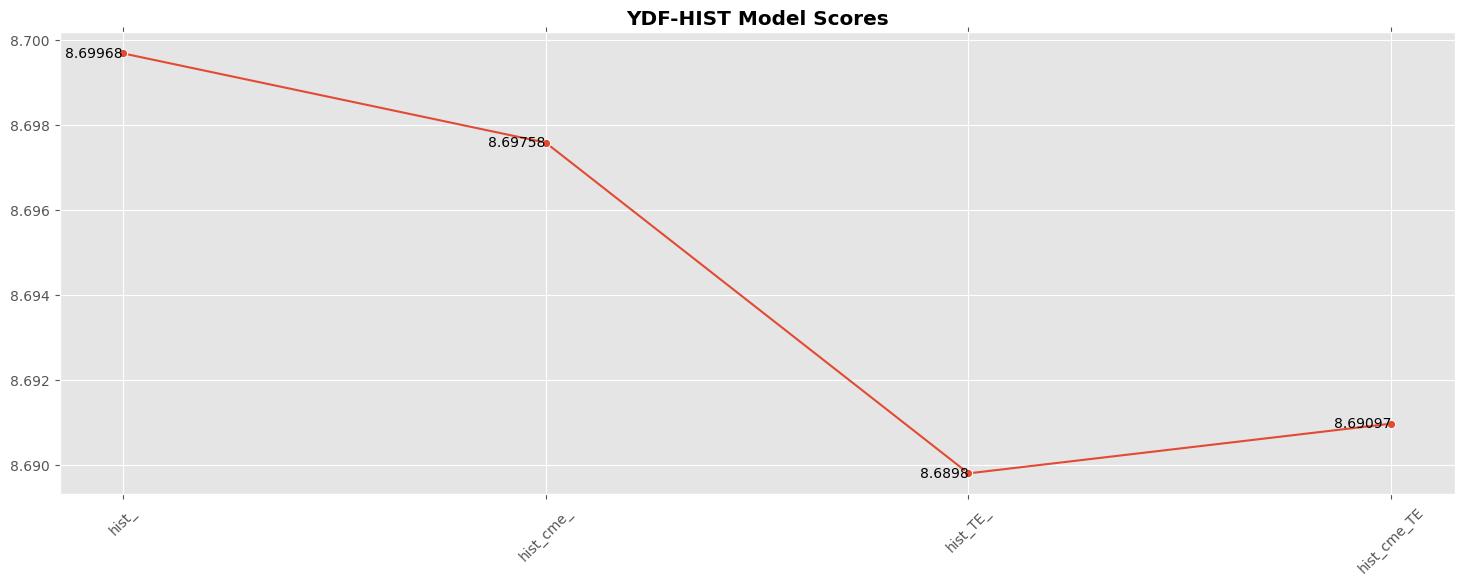

In [34]:
## -- Get models scores --
all_model_scores = {} 

for k, v in all_model_predictions.items():
    for x, y in v.items():
        if x == 'score':
            # print(k, y)
            all_model_scores[k] = y

plt.figure(figsize=(18, 6))
sns.lineplot(all_model_scores, marker='o')
# pd.Series(all_model_scores).plot(marker='o')
plt.title('YDF-HIST Model Scores', fontweight='semibold')
plt.tick_params('x', rotation=45, reset=True)

for i, score in enumerate(all_model_scores.values()):
    plt.text(float(i), score+4e-5, score, ha='right', va='center_baseline')
    
plt.show()

In [35]:
## -- Get oof predictions --
all_model_oof = pd.DataFrame()

for i, (k, v) in enumerate(all_model_predictions.items()):
    for x, y in v.items():
        if x == 'oof_preds':
            n = f"{k}_{str(list(all_model_scores.values())[i]).split('.')[1]}"
            all_model_oof = pd.concat([all_model_oof, pd.DataFrame({n: y})], axis=1)

all_model_oof.to_parquet(f"oof_YDF-HIST_models.parquet", index=False)
all_model_oof.head()

,hist__69968,hist_cme__69758,hist_TE__6898,hist_cme_TE_69097
0,85.353533,85.687152,85.409210,85.374487
1,64.307580,64.505596,62.963127,63.299097
2,75.526277,75.458655,75.434530,75.263758
3,47.751790,47.382847,48.663455,48.409256
4,96.786040,96.299242,95.752202,96.312584


In [36]:
## -- Get test predictions --
all_model_test = pd.DataFrame()

for i, (k, v) in enumerate(all_model_predictions.items()):
    for x, y in v.items():
        if x == 'test_preds':
            n = f"{k}_{str(list(all_model_scores.values())[i]).split('.')[1]}"
            all_model_test = pd.concat([all_model_test, pd.DataFrame({n: y})], axis=1)

all_model_test.to_parquet(f"test_YDF-HIST_models.parquet", index=False)
all_model_test.head()

,hist__69968,hist_cme__69758,hist_TE__6898,hist_cme_TE_69097
0,70.473159,70.286991,70.855875,71.198036
1,69.394816,69.790828,68.684939,69.029887
2,88.894744,88.711039,88.880809,88.855335
3,56.133885,56.109403,56.027353,55.997858
4,49.228763,49.919804,47.507002,47.440203


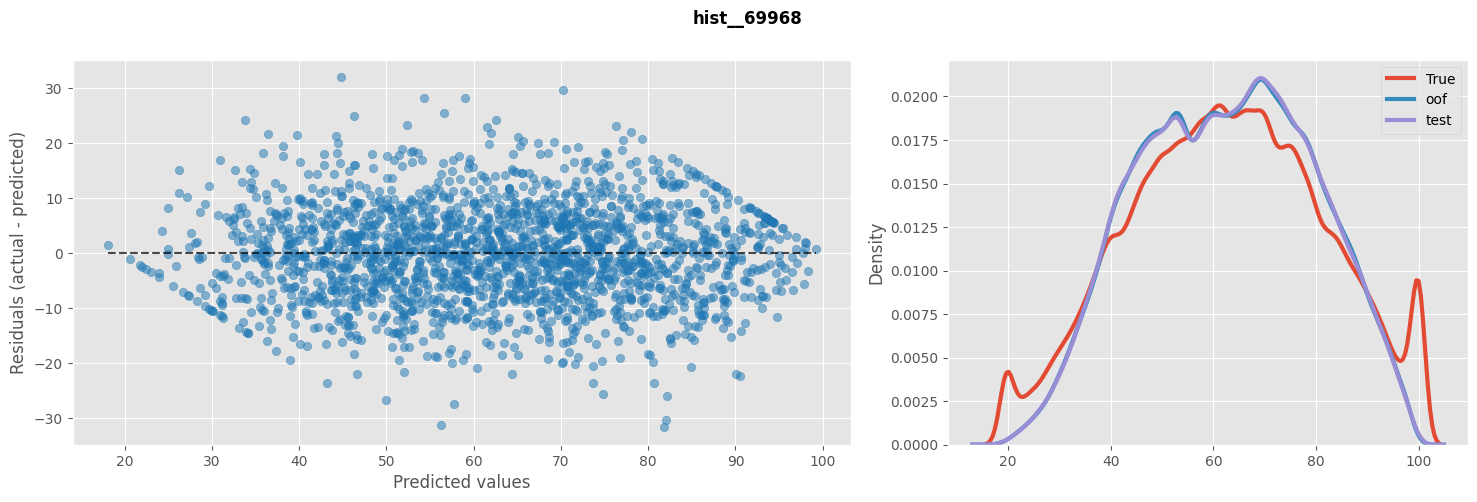

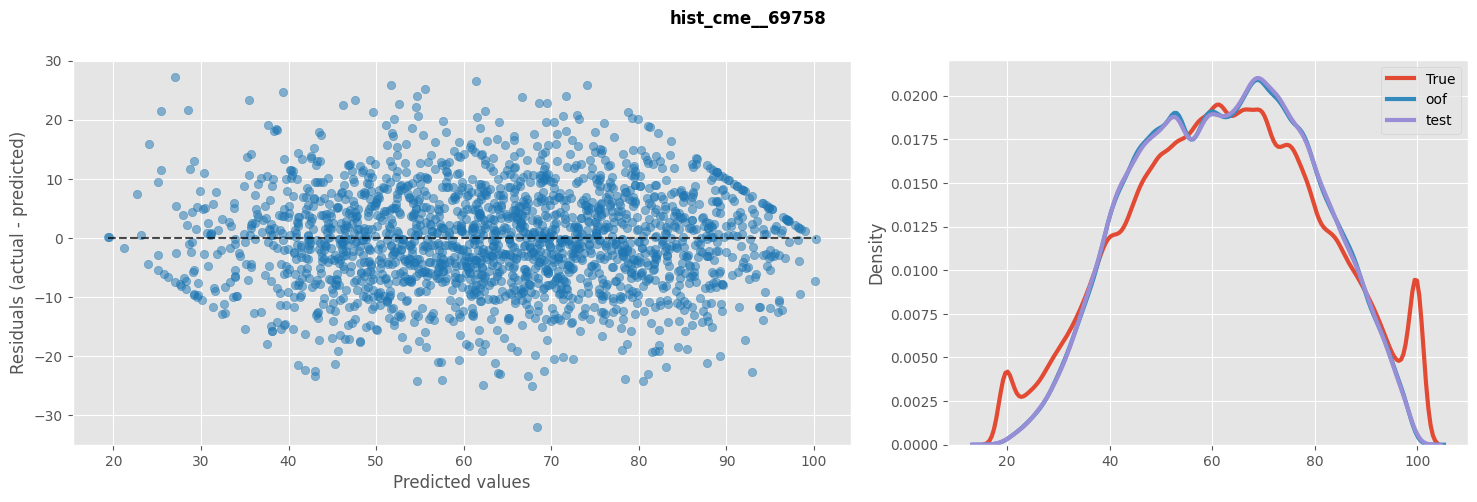

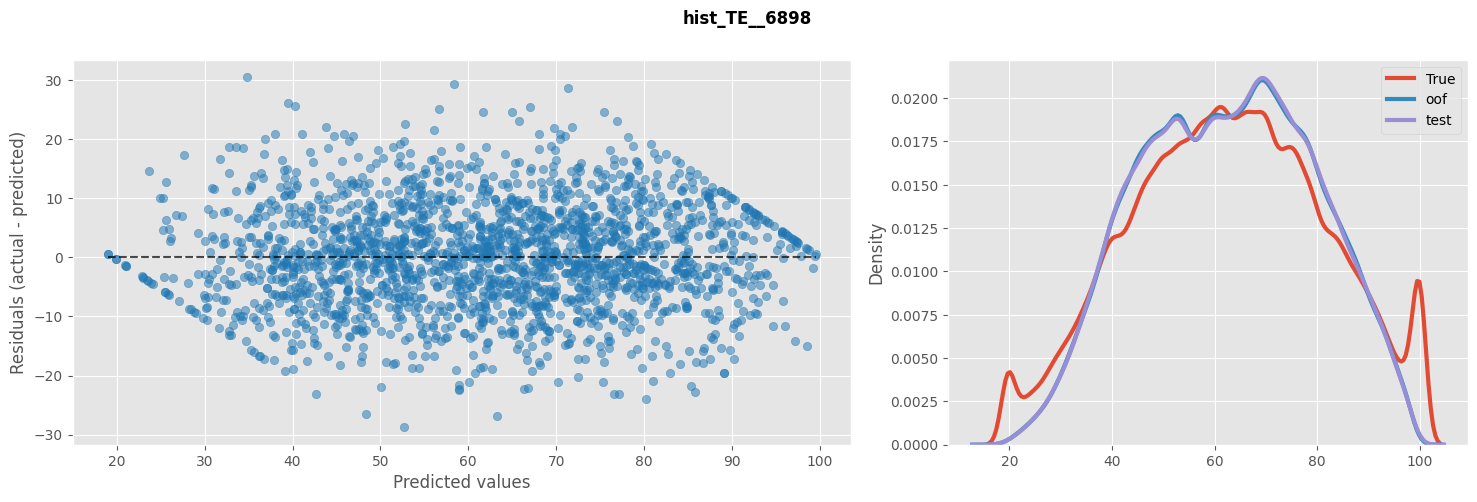

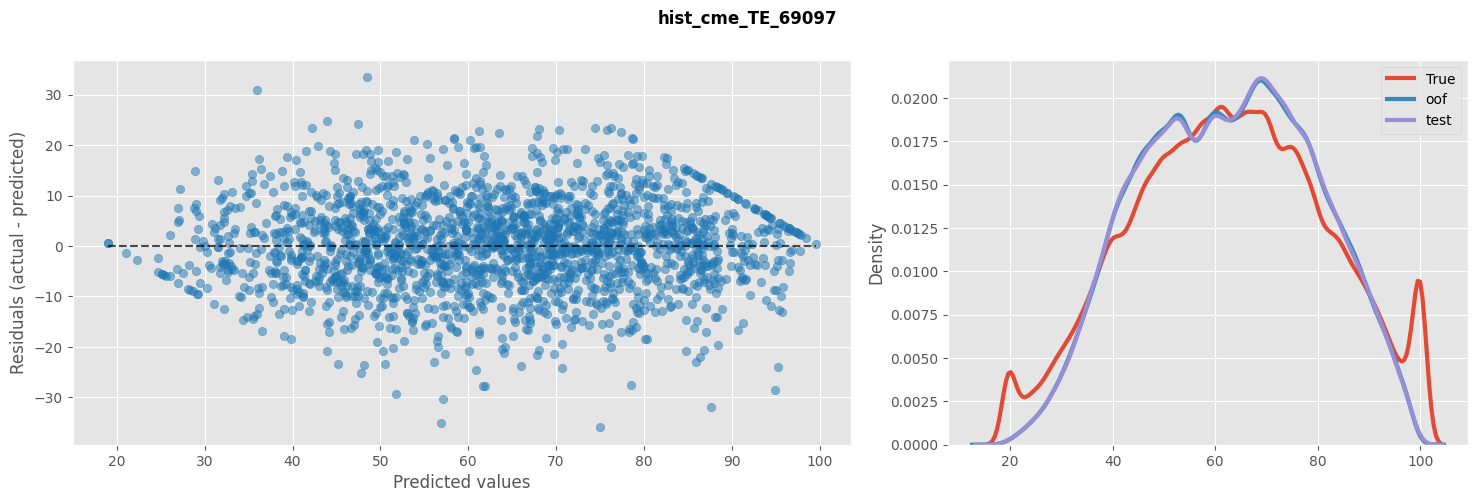

In [37]:
## -- Plot predictions --
for n in all_model_test.columns:
    _, axs = plt.subplots(1, 2, figsize=(18, 5), gridspec_kw={'width_ratios':[0.6, 0.4], 'wspace':0.15})
    plot_ = PredictionErrorDisplay.from_predictions(
        train[TARGET],
        all_model_oof[n],
        ax=axs[0],
        subsample=2000,
        # kind="actual_vs_predicted",
        scatter_kwargs={"alpha": 0.5},
        # line_kwargs={'color': 'r'}
    )
    sns.kdeplot(train[TARGET], ax=axs[1], linewidth=3, label=f"True")
    sns.kdeplot(all_model_oof[n], ax=axs[1], linewidth=3, label=f"oof")
    sns.kdeplot(all_model_test[n], ax=axs[1], linewidth=3, label=f"test")
    plt.suptitle(n, fontweight='semibold')
    plt.xlabel('')
    plt.legend()
    plt.show()
    print()

In [38]:
# ## -- Plot SHAP values --
# get_model = list(all_model_predictions.keys())

# MAX = 20
# for k, v in all_model_predictions.items():
#     for x, y in v.items():
#         if 'xtra' in k or 'hist' in k:
#             if x == 'model':
#                 ## -- Shap Explainer --
#                 explainer = shap.TreeExplainer(y)
#                 explanation = explainer(test.iloc[:1000])
            
#                 ## -- Bar plot --
#                 plt.subplot(121)
#                 shap.plots.bar(
#                     explanation[0],
#                     max_display=MAX,
#                     show=False
#                 )
#                 plt.title('Bar - Overall impact on model predictions')
            
#                 ## -- Beeswarm plot --
#                 plt.subplot(122)
#                 shap.plots.beeswarm(
#                     explanation,
#                     max_display=MAX,
#                     order=explanation.abs.max(0),
#                     color_bar=False,
#                     plot_size=(20, 10),
#                     show=False,
#                 )
            
#                 plt.title('Beeswarm - Most impactful features')
#                 plt.suptitle(f"{k}", fontweight='bold', fontsize=15, color='r')
#                 plt.tight_layout(pad=1.5)
#                 plt.show()
#                 print()